<a href="https://colab.research.google.com/github/npappin-wsu/BroadbandDataQuickstart/blob/main/Broadband_Data_Quickstart_Hour_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Broadband Data Quickstart

## Setup

In [ ]:
!git clone https://github.com/npappin-wsu/BroadbandDataQuickstart.git data
!git -C data pull

fatal: destination path 'data' already exists and is not an empty directory.
Already up to date.


In [ ]:
!pip install -r data/requirements.txt

Setup API Keys first

In [108]:
import os, pathlib, h3pandas, pygris
from google.colab import userdata
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
os.environ["BDC_USERNAME"] = userdata.get('bdc_email')
os.environ["BDC_API_KEY"] = userdata.get('bdc_hash')

In [ ]:
import bdcdata

{'User-Agent': 'python-bdc', 'Accept-Encoding': 'gzip, deflate, br, zstd', 'Accept': '*/*', 'Connection': 'keep-alive', 'hash_value': '2y/1NvvejDWWuZt4vXrkL9LQ4QNeprc1qPzW8w8Zvz0=', 'username': 'nick.pappin@wsu.edu'}
DEBUG:bdcdata:{'User-Agent': 'python-bdc', 'Accept-Encoding': 'gzip, deflate, br, zstd', 'Accept': '*/*', 'Connection': 'keep-alive', 'hash_value': '2y/1NvvejDWWuZt4vXrkL9LQ4QNeprc1qPzW8w8Zvz0=', 'username': 'nick.pappin@wsu.edu'}
Session created.
INFO:bdcdata:Session created.
INFO:bdcdata:Collecting metadata...
{'data': [{'data_type': 'availability', 'as_of_date': '2022-06-30'}, {'data_type': 'availability', 'as_of_date': '2022-12-31'}, {'data_type': 'availability', 'as_of_date': '2023-06-30'}, {'data_type': 'availability', 'as_of_date': '2023-12-31'}, {'data_type': 'availability', 'as_of_date': '2024-06-30'}, {'data_type': 'availability', 'as_of_date': '2024-12-31'}, {'data_type': 'challenge', 'as_of_date': '2022-11-30'}, {'data_type': 'challenge', 'as_of_date': '2022-12

## Pull data

In [ ]:
waData = bdcdata.availability.fixed(states=[53], technology='fixed', release=['2024-12-31'], cache=True)

INFO:bdcdata:Collecting availability...
State: [53]
DEBUG:bdcdata:State: [53]
Technology: fixed
DEBUG:bdcdata:Technology: fixed
Release: ['2024-12-31']
DEBUG:bdcdata:Release: ['2024-12-31']
State: Washington({'file_id': 1224952, 'category': 'State', 'subcategory': 'Location Coverage', 'technology_type': 'Fixed Broadband', 'technology_code': '10', 'technology_code_desc': 'Copper', 'speed_tier': None, 'state_fips': '53', 'state_name': 'Washington', 'provider_id': None, 'provider_name': None, 'file_type': 'csv', 'file_name': 'bdc_53_Copper_fixed_broadband_D24_03sep2025', 'record_count': '1102663'})), Technology: 10, Release: 2024-12-31
DEBUG:bdcdata:State: Washington({'file_id': 1224952, 'category': 'State', 'subcategory': 'Location Coverage', 'technology_type': 'Fixed Broadband', 'technology_code': '10', 'technology_code_desc': 'Copper', 'speed_tier': None, 'state_fips': '53', 'state_name': 'Washington', 'provider_id': None, 'provider_name': None, 'file_type': 'csv', 'file_name': 'bdc_53

In [ ]:
waData.sample(n=20)

,frn,provider_id,brand_name,location_id,technology,max_advertised_download_speed,max_advertised_upload_speed,low_latency,business_residential_code,state_usps,block_geoid,h3_res8_id
1884593,0025646373,130235,Spectrum,1296176378,40,1000,35,True,B,WA,530210202011022,882888b983fffff
15907431,0026832444,380048,Gigabeam Internet,1305915305,70,300,300,True,X,WA,530779400051023,88288982a1fffff
2211245,0003768165,130317,Xfinity,1073184797,40,1200,35,True,X,WA,530350907004006,8828d54687fffff
2283842,0003768165,130317,Xfinity,1073193160,40,2000,300,True,X,WA,530350802001027,8828d50b1bfffff
12822411,0026043968,430076,Starlink,1349416371,61,100,25,True,R,WA,530110405052024,8828f07317fffff
11891462,0004963088,290111,Viasat Inc,1366810740,60,100,3,False,R,WA,530330292082004,8828d5c835fffff
17445737,0005937974,130077,AT&T,1367067485,71,25,3,True,R,WA,530330110022023,8828d5508dfffff
7281473,0004963088,290111,Viasat Inc,1330205050,60,100,3,False,R,WA,530530707035000,8828d5d8dbfffff
15259700,0023973480,290093,Pogozone powered by Neubeam,1310106822,70,40,7,True,X,WA,530730007001021,8828d17b69fffff
14008661,0026043968,430076,Starlink,1312946203,61,100,25,True,R,WA,530579524031006,8828d1526dfffff


In [ ]:
waData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19853226 entries, 0 to 19853225
Data columns (total 12 columns):
 #   Column                         Dtype          
---  ------                         -----          
 0   frn                            object         
 1   provider_id                    UInt32         
 2   brand_name                     object         
 3   location_id                    UInt32         
 4   technology                     UInt16         
 5   max_advertised_download_speed  UInt32         
 6   max_advertised_upload_speed    UInt32         
 7   low_latency                    boolean        
 8   business_residential_code      string[pyarrow]
 9   state_usps                     category       
 10  block_geoid                    object         
 11  h3_res8_id                     object         
dtypes: UInt16(1), UInt32(4), boolean(1), category(1), object(4), string[pyarrow](1)
memory usage: 1.2+ GB


In [ ]:
locationLookup = waData[['location_id', 'block_geoid', 'h3_res8_id']].drop_duplicates(ignore_index=True)

In [ ]:
locationLookup

,location_id,block_geoid,h3_res8_id
0,1027407142,530519705001008,8812db8c59fffff
1,1121311109,530179508002000,8828d68111fffff
2,1122544844,530199702002003,8812da8343fffff
3,1296237355,530079604001044,8828d60c6dfffff
4,1296248370,530299710001051,8828d1d5d1fffff
...,...,...,...
2566302,1564174977,530079603021002,8828d6081bfffff
2566303,1564299037,530459604031000,8828d51231fffff
2566304,1342737372,530630104032044,8812db701dfffff
2566305,1342746597,530630112024002,8812db0cdbfffff


## Census Data

In [ ]:
washington = pygris.blocks(state='53')
waState = pyrgis.states()

Using the default year of 2024
HTTP download failed, trying FTP as fallback...


<Axes: >

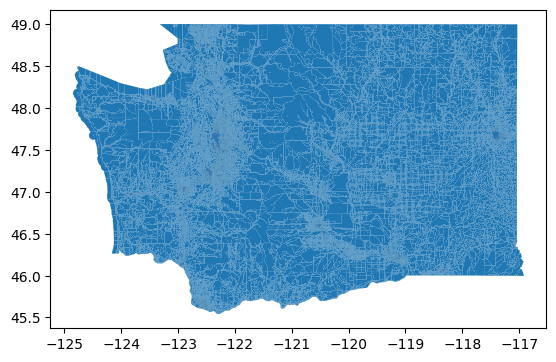

In [52]:
washington.plot()

In [57]:
washington

,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOID20,GEOIDFQ20,NAME20,MTFCC20,UR20,UACE20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,HOUSING20,POP20,geometry
0,53,021,020603,1042,530210206031042,1000000US530210206031042,Block1042,G5040,U,44479,S,11749,0,+46.2657791,-119.2094001,10,25,"POLYGON ((-119.21016 46.26544, -119.21013 46.2..."
1,53,021,020603,1008,530210206031008,1000000US530210206031008,Block1008,G5040,U,44479,S,224396,0,+46.2721164,-119.2139351,240,788,"POLYGON ((-119.21915 46.27254, -119.21896 46.2..."
2,53,021,020608,1017,530210206081017,1000000US530210206081017,Block1017,G5040,R,None,S,1025191,0,+46.4539463,-119.0283308,16,47,"POLYGON ((-119.03663 46.45433, -119.03608 46.4..."
3,53,021,020606,2006,530210206062006,1000000US530210206062006,Block2006,G5040,U,44479,S,12403,0,+46.2832583,-119.2139323,10,28,"POLYGON ((-119.21494 46.28364, -119.21289 46.2..."
4,53,021,020503,3019,530210205033019,1000000US530210205033019,Block3019,G5040,U,44479,S,61667,0,+46.2375134,-119.1786217,33,82,"POLYGON ((-119.18048 46.2371, -119.18046 46.23..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158088,53,011,041005,2004,530110410052004,1000000US530110410052004,Block2004,G5040,R,None,S,0,37052,+45.7818053,-122.7539555,0,0,"POLYGON ((-122.75456 45.78204, -122.75454 45.7..."
158089,53,011,040305,2000,530110403052000,1000000US530110403052000,Block2000,G5040,R,None,S,0,553651,+45.8567593,-122.7692939,0,0,"POLYGON ((-122.78012 45.84956, -122.78008 45.8..."
158090,53,011,040304,1023,530110403041023,1000000US530110403041023,Block1023,G5040,R,None,S,0,204439,+45.7880514,-122.7747319,0,0,"POLYGON ((-122.77898 45.79125, -122.77619 45.7..."
158091,53,011,040304,1022,530110403041022,1000000US530110403041022,Block1022,G5040,R,None,S,0,74157,+45.8047983,-122.7665468,0,0,"POLYGON ((-122.77619 45.79321, -122.77487 45.7..."


In [73]:
blockLocations = locationLookup.block_geoid.value_counts().reset_index()

In [74]:
blockLocations

,block_geoid,count
0,530110401014003,1178
1,530530731291006,943
2,530730104112000,781
3,530050108112000,713
4,530530724063000,632
...,...,...
121440,530330328003195,1
121441,530210208023033,1
121442,530750007001333,1
121443,530399501031013,1


In [75]:
blockLocations = blockLocations.merge(washington, how='left', left_on='block_geoid', right_on='GEOID20')


In [76]:
blockLocations

,block_geoid,count,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOID20,GEOIDFQ20,NAME20,MTFCC20,UR20,UACE20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,HOUSING20,POP20,geometry
0,530110401014003,1178,53,011,040101,4003,530110401014003,1000000US530110401014003,Block4003,G5040,R,None,S,24304171,24397,+45.9451345,-122.4043196,190,477,"POLYGON ((-122.4525 45.96029, -122.45244 45.96..."
1,530530731291006,943,53,053,073129,1006,530530731291006,1000000US530530731291006,Block1006,G5040,U,80389,S,743705,0,+47.0856363,-122.2802616,347,1112,"POLYGON ((-122.29039 47.08723, -122.29024 47.0..."
2,530730104112000,781,53,073,010411,2000,530730104112000,1000000US530730104112000,Block2000,G5040,U,07759,S,1351585,0,+48.9287649,-122.7358518,438,459,"POLYGON ((-122.74543 48.92864, -122.74454 48.9..."
3,530050108112000,713,53,005,010811,2000,530050108112000,1000000US530050108112000,Block2000,G5040,R,None,S,4496445,0,+46.2196179,-119.3240027,179,505,"POLYGON ((-119.34761 46.22571, -119.3476 46.22..."
4,530530724063000,632,53,053,072406,3000,530530724063000,1000000US530530724063000,Block3000,G5040,U,80389,S,5365774,0,+47.3034599,-122.6524294,640,1711,"POLYGON ((-122.66946 47.29903, -122.66942 47.3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121440,530330328003195,1,53,033,032800,3195,530330328003195,1000000US530330328003195,Block3195,G5040,R,None,S,50416,0,+47.7136635,-121.1705034,2,0,"POLYGON ((-121.17666 47.71522, -121.17638 47.7..."
121441,530210208023033,1,53,021,020802,3033,530210208023033,1000000US530210208023033,Block3033,G5040,R,None,S,2257742,0,+46.7004070,-118.7051981,1,0,"POLYGON ((-118.7152 46.70681, -118.69431 46.70..."
121442,530750007001333,1,53,075,000700,1333,530750007001333,1000000US530750007001333,Block1333,G5040,R,None,S,1192608,0,+46.9647088,-117.2175257,1,2,"POLYGON ((-117.22399 46.9661, -117.22388 46.96..."
121443,530399501031013,1,53,039,950103,1013,530399501031013,1000000US530399501031013,Block1013,G5040,R,None,S,120700,0,+45.8915524,-120.7264971,1,10,"POLYGON ((-120.73074 45.89053, -120.7305 45.89..."


In [87]:
blockLocations = gpd.GeoDataFrame(blockLocations)

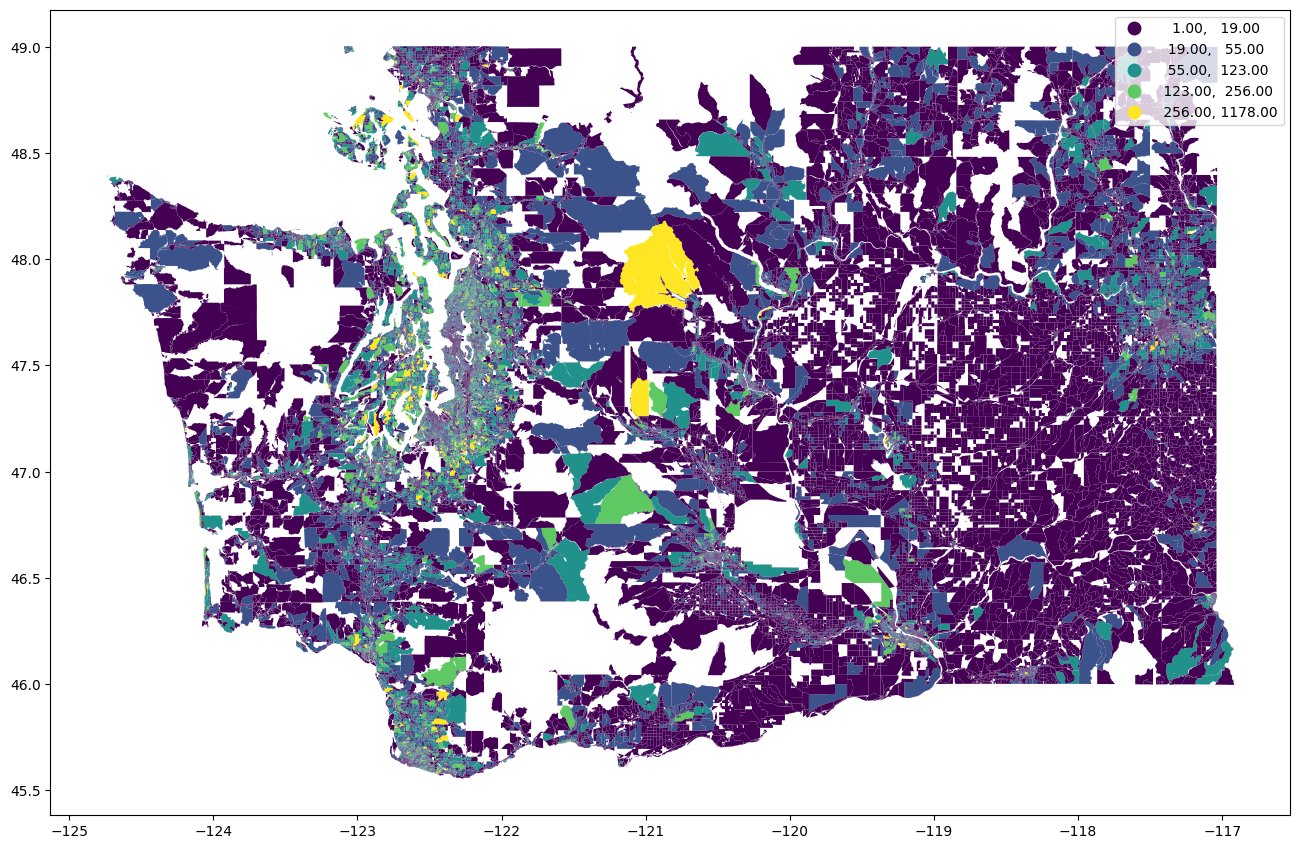

In [100]:
fig, ax2 = plt.subplots(figsize=(16, 16))
blockLocations.plot(ax = ax2, column='count', scheme='FisherJenks', legend=True)
fig.show()

In [101]:
plt.close(fig)

In [111]:
blockLocations['countPopNorm'] = blockLocations['count'] / blockLocations.POP20.replace(0, np.nan)
blockLocations['countHousingNorm'] = blockLocations['count'] / blockLocations.HOUSING20.replace(0, np.nan)

In [112]:
blockLocations.sample(n=5)

,block_geoid,count,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOID20,GEOIDFQ20,NAME20,MTFCC20,...,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,HOUSING20,POP20,geometry,countNorm,countPopNorm,countHousingNorm
22236,530330029001009,30,53,033,002900,1009,530330029001009,1000000US530330029001009,Block1009,G5040,...,16150,0,+47.6887480,-122.3593137,31,70,"POLYGON ((-122.36065 47.68911, -122.35798 47.6...",0.428571,0.428571,0.967742
19783,530110412062004,32,53,011,041206,2004,530110412062004,1000000US530110412062004,Block2004,G5040,...,38882,0,+45.6334305,-122.5719773,32,95,"POLYGON ((-122.5734 45.63425, -122.57275 45.63...",0.336842,0.336842,1.000000
55983,530670106005046,13,53,067,010600,5046,530670106005046,1000000US530670106005046,Block5046,G5040,...,12419,0,+47.0466492,-122.9241703,11,28,"POLYGON ((-122.92473 47.0473, -122.92358 47.04...",0.464286,0.464286,1.181818
96302,530110420002015,4,53,011,042000,2015,530110420002015,1000000US530110420002015,Block2015,G5040,...,6032,0,+45.6504280,-122.6839274,7,13,"POLYGON ((-122.68441 45.65045, -122.68441 45.6...",0.307692,0.307692,0.571429
17990,530599502003168,35,53,059,950200,3168,530599502003168,1000000US530599502003168,Block3168,G5040,...,1875209,359931,+45.6026290,-122.0936720,36,54,"POLYGON ((-122.11025 45.60173, -122.10784 45.6...",0.648148,0.648148,0.972222


In [121]:
int(blockLocations.shape[0]*.1)

12144

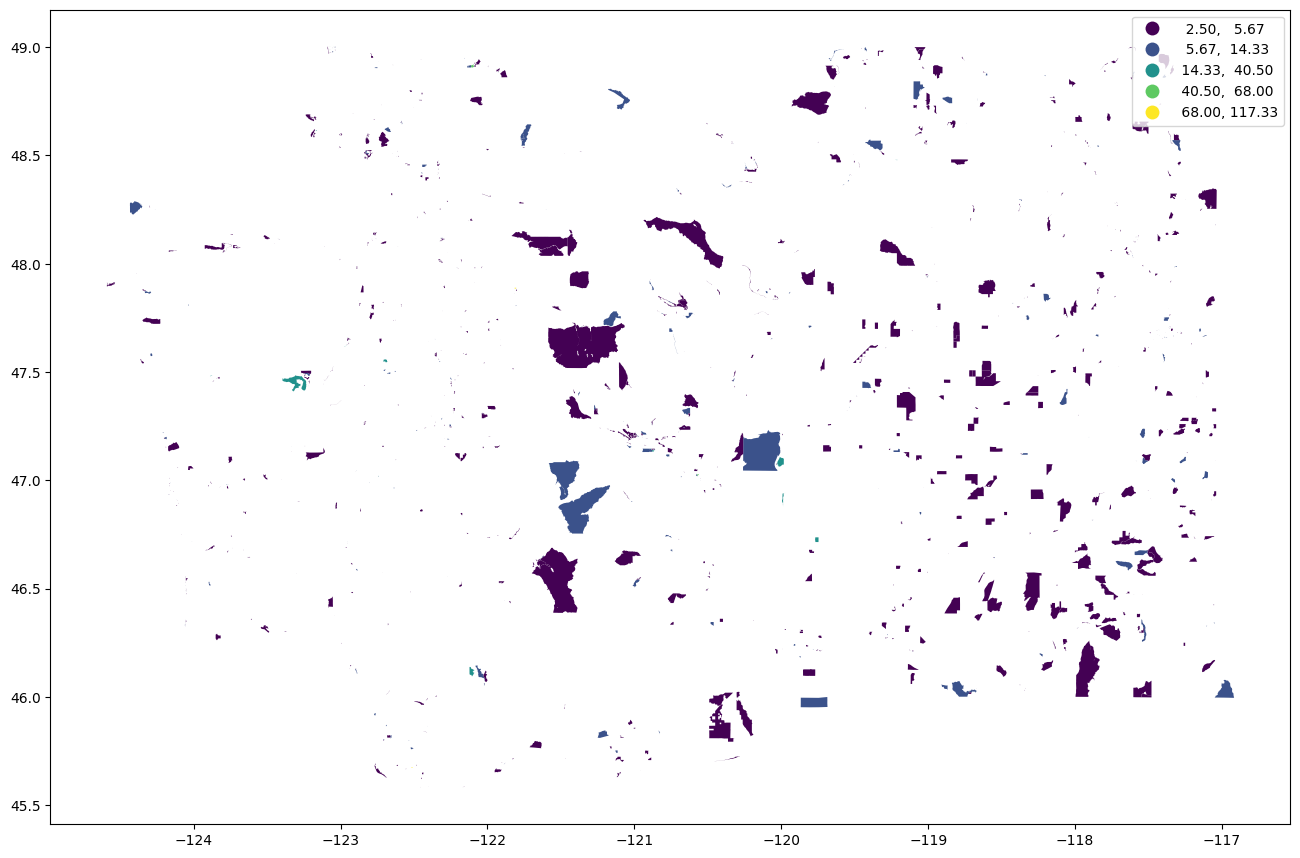

In [124]:
fig, ax2 = plt.subplots(figsize=(16, 16))
num = int(blockLocations.shape[0]*.01)
blockLocations.nlargest(num, 'countPopNorm').plot(ax = ax2, column='countPopNorm', scheme='FisherJenks', legend=True)
fig.show()

In [ ]:
plt.close()

In [ ]:
fig, ax2 = plt.subplots(figsize=(16, 16))
blockLocations..plot(ax = ax2, column='countHousingNorm', scheme='FisherJenks', legend=True)

## H3 Data

In [ ]:
fpLocations = pd.read_csv(pathlib.Path('data', 'fp_locations.csv'))

In [ ]:
fpLocations.drop_duplicates()

,location_id,project_id,classification,technology,upload_speed_anticipated,download_speed_anticipated,low_latency
0,1024099225,CM61-BEAD-WA-26-96212-001,0,61,20,150,1
1,1024099256,CM61-BEAD-WA-26-96212-001,0,61,20,150,1
2,1024099803,CM61-BEAD-WA-26-96212-001,0,61,20,150,1
3,1024099831,CM61-BEAD-WA-26-96212-001,0,61,20,150,1
4,1024099838,CM61-BEAD-WA-26-96212-001,0,61,20,150,1
...,...,...,...,...,...,...,...
165968,1414834970,CM61-BEAD-WA-26-96212-171,0,71,20,100,1
165969,1414834977,CM61-BEAD-WA-26-96212-171,0,71,20,100,1
165970,1414835005,CM61-BEAD-WA-26-96212-171,0,71,20,100,1
165971,1414835015,CM61-BEAD-WA-26-96212-171,0,50,1000,1000,1


In [ ]:
locations = fpLocations[['location_id', 'technology']].merge(locationLookup, how='left', on='location_id')

In [ ]:
locations.shape

(165973, 4)

In [ ]:
locations.drop_duplicates()

,location_id,technology,block_geoid,h3_res8_id
0,1024099225,61,530019501001104,88288b1169fffff
1,1024099256,61,530019503011093,8828882d85fffff
2,1024099803,61,530019501001244,88288a2621fffff
3,1024099831,61,530019501001158,88288bc603fffff
4,1024099838,61,530019502002050,88288b8f5bfffff
...,...,...,...,...
165968,1414834970,71,530379753003007,8828892c1bfffff
165969,1414834977,71,530379753001078,88288921a9fffff
165970,1414835005,71,530379753001085,8828892033fffff
165971,1414835015,50,530379753001116,8828892a1bfffff


In [38]:
pivoted = locations[['h3_res8_id', 'technology', 'location_id']].pivot_table(index='h3_res8_id', columns='technology', values='location_id', aggfunc='count', fill_value=0, )
pivoted.columns = pivoted.columns.astype(str)

In [ ]:
pivoted.to_excel('test.xlsx')

In [39]:
pivoted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35178 entries, 8812d80013fffff to 8828f66f5dfffff
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   50      35178 non-null  int64
 1   61      35178 non-null  int64
 2   70      35178 non-null  int64
 3   71      35178 non-null  int64
 4   72      35178 non-null  int64
dtypes: int64(5)
memory usage: 1.6+ MB


In [41]:
pivoted['70s'] = pivoted.loc[:, "70"] + pivoted.loc[:, "71"] + pivoted.loc[:, "72"]

In [45]:
pivoted['max'] = pivoted[["50", "70s", "61"]].idxmax(axis=1)

In [48]:
techHash = {
    '50': 'Fiber',
    '61': 'LEO',
    '70': 'ULFW',
    '71': 'LFW',
    '72': 'LBRW',
    '70s': 'Wireless'
}

In [50]:
pivoted.rename(columns=techHash, inplace=True)

In [66]:
pivoted

technology,Fiber,LEO,ULFW,LFW,LBRW,Wireless,max
h3_res8_id,,,,,,,
8812d80013fffff,0,0,0,3,0,3,70s
8812d80017fffff,0,0,0,2,0,2,70s
8812d8001bfffff,0,0,0,1,0,1,70s
8812d80081fffff,0,0,0,4,0,4,70s
8812d80085fffff,0,0,0,2,0,2,70s
...,...,...,...,...,...,...,...
8828f66f1bfffff,0,1,0,0,0,0,61
8828f66f43fffff,0,3,0,0,0,0,61
8828f66f53fffff,0,3,0,0,0,0,61


In [65]:
gpd.GeoDataFrame(pivoted.h3.h3_to_geo_boundary()).explore(column='max', categorical=True, tiles="CartoDB dark_matter").save("h3.html")